<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/01_Clasificación_Bayesiana/incremento_fijo.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [55]:
#######################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)            #
# E-mail: wgomez@cinvestav.mx                         #
# Curso: Análisis de datos                            #
# Tópico: Algoritmo perceptrón de incremento fijo     #
#######################################################

Carga bibliotecas necesarias

In [56]:
import numpy as np
import matplotlib.pyplot as plt

Genera conjunto de datos lnealmente separables con dos clases

In [57]:
c1 = np.array([[0.1, 0.2],
               [0.2, 0.3],
               [0.25, 0.33],
               [0.3, 0.28],
               [0.35, 0.19]]).T # Clase 1

c2 = np.array([[0.3, 0.45],
               [0.35, 0.4],
               [0.4, 0.44],
               [0.42, 0.39],
               [0.47, 0.35]]).T # Clase 2

d = c1.shape[0] # Número de variables
n = c1.shape[1] + c2.shape[1] # Número de muestras

Aumenta los vectores a dimensionalidad $d+1$ para cálculo del desvío e invierte el signo de una de las clases para encontrar una solución tal que $\mathbf{w}^T \mathbf{x}_i > 0, \; \forall i$

In [58]:
x1 = np.vstack([np.ones((1, c1.shape[1])), c1]) # Clase 1 aumentada a d+1
x2 = -np.vstack([np.ones((1, c2.shape[1])), c2]) # Clase 2 aumentada a d+1 e invertida
x = np.hstack([x1, x2]) # Conjunto de datos completo

Entrenamiento del vector de pesos $\mathbf{w}$ usando el algoritmo perceptón de incremento fijo

In [59]:
W = np.zeros((d + 1, 1)) # Inicialización del vector de pesos
k = 0
while not np.all((W.T @ x) > 0):
    idx = k % n # Índice de la siguiente muestra presentada de manera cíclica
    if (W.T @ x[:, [idx]]) <= 0:  # Si la muestra es mal clasificada
        W = W + x[:, [idx]] # Actualiza el vector de pesos
    k = k + 1 # Incrementa k

print("Vector de pesos:")
print(W)

Vector de pesos:
[[ 1.  ]
 [-1.3 ]
 [-1.55]]


Grafica la frontera de desición generada por el vector de pesos $\mathbf{w}$

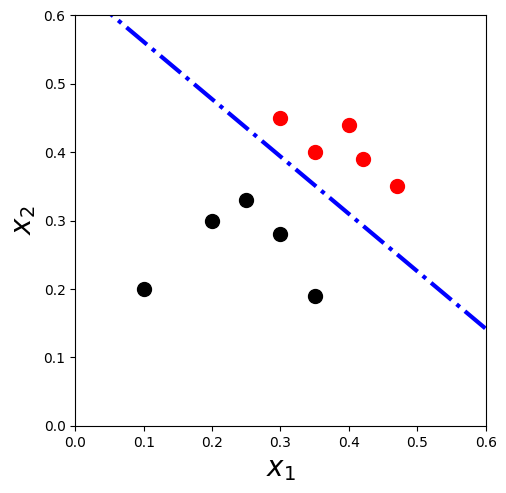

In [60]:
fig = plt.figure(facecolor='white', figsize=(5.33, 5.33))
ax = fig.add_subplot(111)
ax.plot(c1[0, :], c1[1, :], 'ko', markerfacecolor='k', markersize=10, label='c1')
ax.plot(c2[0, :], c2[1, :], 'o', markeredgecolor='r', markerfacecolor='r', markersize=10, label='c2')
x_coords = [0, -float(W[0].item()) / float(W[1].item())]
y_coords = [-float(W[0].item()) / float(W[2].item()), 0]
ax.plot(x_coords, y_coords, color='b', linestyle='-.', linewidth=3)
ax.set_xticks(np.arange(0, 1, 0.1))
ax.set_yticks(np.arange(0, 1, 0.1))
ax.set_xlim([0, 0.6])
ax.set_ylim([0, 0.6])
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('$x_1$', fontsize=20)
ax.set_ylabel('$x_2$', fontsize=20)
plt.show()